# 2025-08-18: Reprocessing Plasma Cell Subsets for Downstream Analysis
#### By [Aishwarya Chander](aishwarya.chander@alleninstitute.org), High Resolution Translational Immunology, Allen Institute for Immunology

**Main aim**: Generate three plasma cell objects — pre-treatment (unharmonized), residual (post-treatment, harmonized), and a combined pre-treatment + residual object (harmonized) — for state visualization, residual cell characterization, and KNN label transfer respectively.

## 1. Imports

In [1]:
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.n_jobs = 30
sc.settings.verbosity = 0

sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=14,
    dpi_save=400,
    figsize=(4, 4),
    format='png',
)

import sys
sys.path.append("../../00-utilities/functions/python/")
from process_scrna_data import process_adata

## 2. Add in the annotations
> We need to add in the cluster annotations as defined in the harmonized objects because thats how the states were defined. Cell states are indepenent of patient heterogeneity.

In [2]:
all_plasma = sc.read_h5ad('../../../data/rna/plasma-subsets/all-plasma-cells.h5ad')

In [3]:
plasma_labels = pd.read_parquet('../../../data/rna/bmmc-labels/plasma_pretx_annotation.parquet')
plasma_labels.head()

,plasma_annotation_leiden,plasma_labels_l3
barcodes,,
1d4b50cae88711eca2fc4e28d07d5108,0,NDMM 0
1d562388e88711eca2fc4e28d07d5108,0,NDMM 0
1d5c134ce88711eca2fc4e28d07d5108,7,NDMM 7
1d5d79e4e88711eca2fc4e28d07d5108,3,NDMM 3
1d63d1fee88711eca2fc4e28d07d5108,7,NDMM 7


In [4]:
all_plasma.obs = all_plasma.obs.join(plasma_labels, how='left')
cluster_dict = {
    '0': 'NDMM 0',
    '1': 'NDMM 1',
    '2': 'NDMM 2',
    '3': 'NDMM 3',
    '4': 'NDMM 4',
    '5': 'NDMM 5',
    '6': 'NDMM 6',
    '7': 'NDMM 7',
    '8': 'NDMM 8',
    '9': 'NDMM 9',
    '10': 'NDMM 10',
    '11': 'NDMM 11'
}

all_plasma.obs['plasma_labels_l3_numeric'] = (
    all_plasma.obs['plasma_annotation_leiden'].map(cluster_dict)
)

## 3. PreTx Plasma with no Harmony
> We'll do this to show how heterogenous the samples are.

In [5]:
pretx = all_plasma[all_plasma.obs['sample.visitDetails'] ==  'MM Pre-Treatment']
pretx = process_adata(pretx, resolution = 0.1)

/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  warnings.warn(


### 3.1. Remove NAs & view data
> Some NAs might exist as we're starting from the raw plasma object which has not been QC'd like the Harmony object. Refer to `02-object-building/01-bmmc/05-plasma-clean_up.ipynb` for more information.

/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


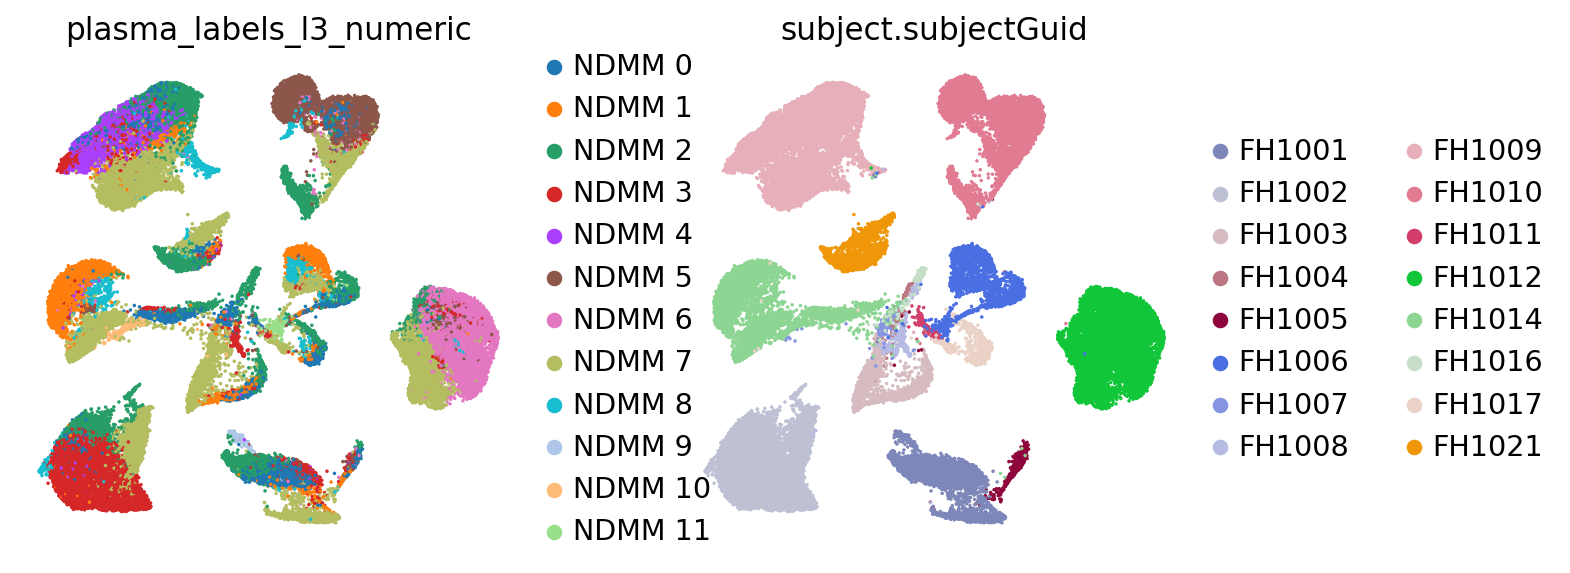

In [6]:
pretx = pretx[~pretx.obs['plasma_labels_l3_numeric'].isna()]
sc.pl.umap(pretx, 
           color = ['plasma_labels_l3_numeric', 'subject.subjectGuid'], 
           size = 10, 
           wspace=0.2)

In [7]:
pretx.write('../../../data/rna/plasma-subsets/plasma-pretx-no_harmony.h5ad')

## 4. Residual Plasma cells
> Residual plasma cells are myeloma cells that persist in the bone marrow after treatment.

In [8]:
residual = all_plasma[~all_plasma.obs['sample.visitDetails'].isin(['Healthy', 'MM Pre-Treatment'])]

In [9]:
residual = process_adata(residual, 
                  subset_hvgs=False, 
                  run_harmony=True, 
                  harmony_key=["sample.sampleKitGuid"], 
                  resolution=0.5, 
                  run_rank_genes=False)

2026-02-26 13:29:05,358 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-02-26 13:29:07,231 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-02-26 13:29:07,249 - harmonypy - INFO - Iteration 1 of 10
2026-02-26 13:29:08,384 - harmonypy - INFO - Iteration 2 of 10
2026-02-26 13:29:09,643 - harmonypy - INFO - Iteration 3 of 10
2026-02-26 13:29:10,647 - harmonypy - INFO - Iteration 4 of 10
2026-02-26 13:29:11,601 - harmonypy - INFO - Iteration 5 of 10
2026-02-26 13:29:12,422 - harmonypy - INFO - Iteration 6 of 10
2026-02-26 13:29:13,518 - harmonypy - INFO - Iteration 7 of 10
2026-02-26 13:29:14,102 - harmonypy - INFO - Iteration 8 of 10
2026-02-26 13:29:14,722 - harmonypy - INFO - Iteration 9 of 10
2026-02-26 13:29:15,700 - harmonypy - INFO - Iteration 10 of 10
2026-02-26 13:29:16,369 - harmonypy - INFO - Stopped before convergence
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previ

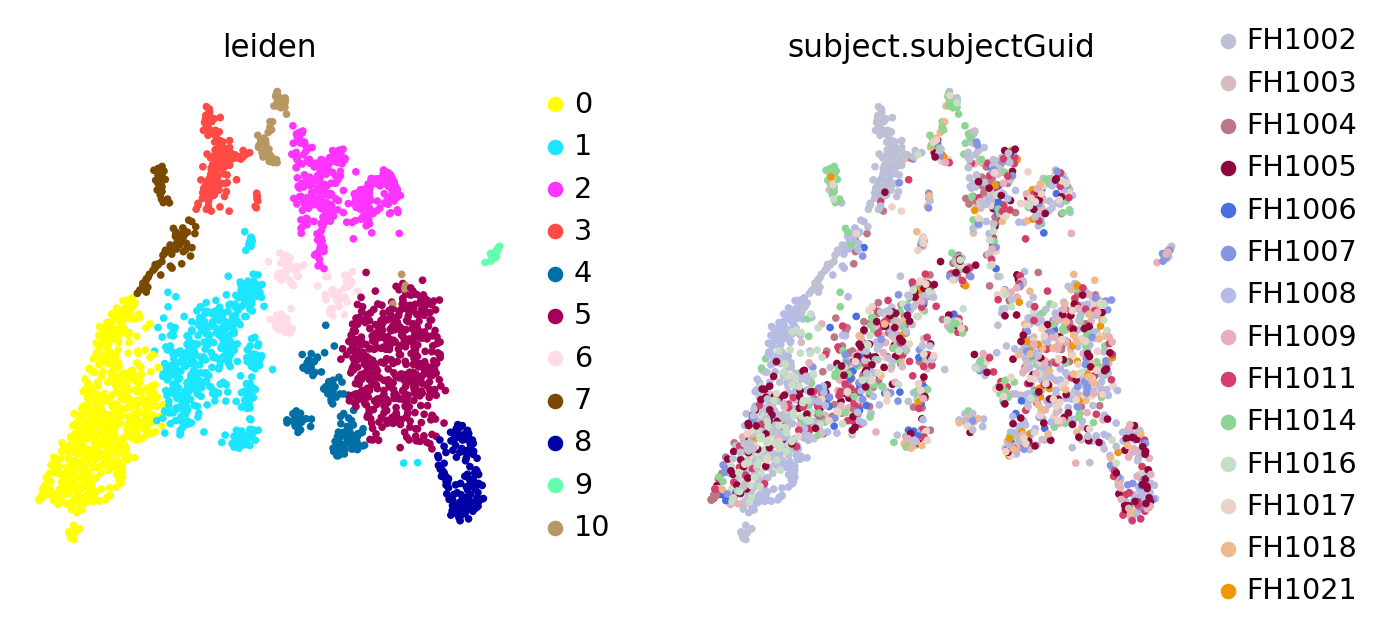

In [10]:
sc.pl.umap(residual, color = ['leiden', 'subject.subjectGuid'])

In [11]:
residual.write('../../../data/rna/plasma-subsets/plasma-residual.h5ad')

## 5. Plasma for KNN label transfer
> To annotate the residual plasma cells to the closest preTx tumor plasma state, we'll build a harmonized object that we can use in the next notebook. We can remove Healthy cells from this because we do not need it for the state label transfer.

In [5]:
knn_obj = all_plasma[all_plasma.obs['sample.visitDetails'] != 'Healthy']

In [6]:
knn_obj = process_adata(knn_obj, 
                  subset_hvgs=False, 
                  run_harmony=True, 
                  harmony_key=["sample.sampleKitGuid"], 
                  resolution=0.5, 
                  run_rank_genes=False)

2026-02-27 01:00:24,680 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-02-27 01:00:28,866 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-02-27 01:00:29,144 - harmonypy - INFO - Iteration 1 of 10
2026-02-27 01:00:51,466 - harmonypy - INFO - Iteration 2 of 10
2026-02-27 01:01:14,251 - harmonypy - INFO - Converged after 2 iterations
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  warnings.warn(


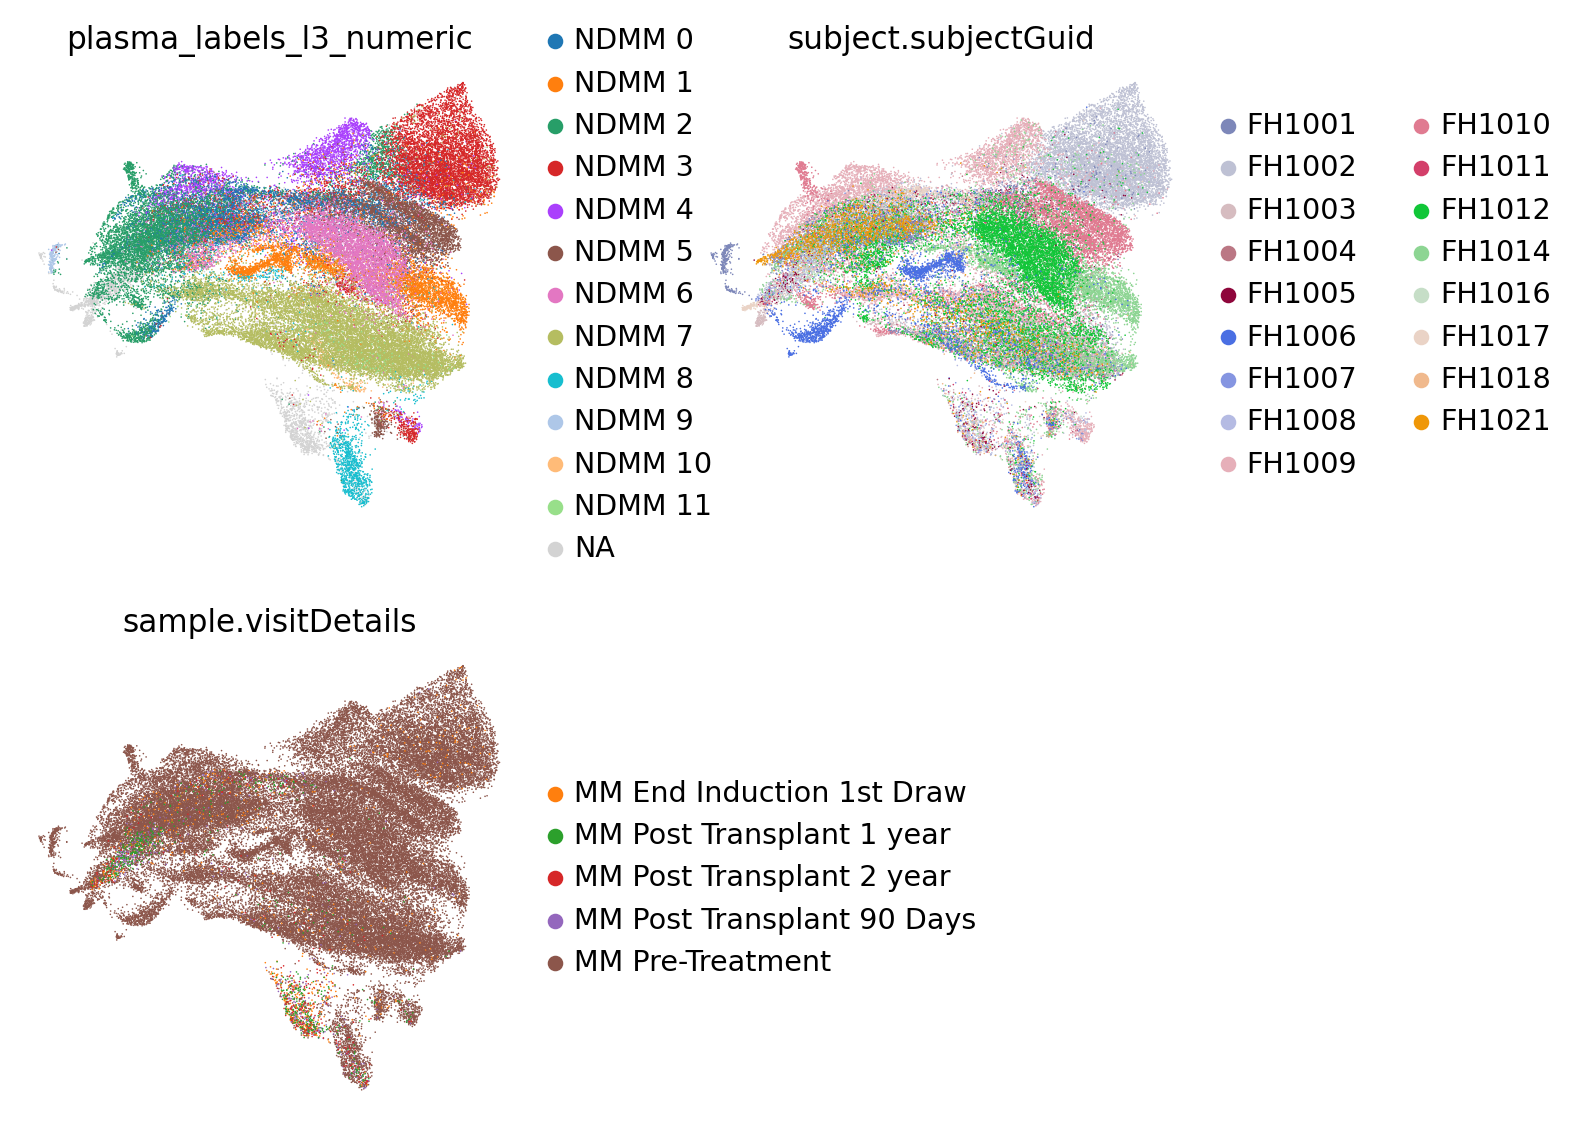

In [7]:
sc.pl.umap(knn_obj, color = ['plasma_labels_l3_numeric', 'subject.subjectGuid', 'sample.visitDetails'], ncols=2)

In [8]:
knn_obj.write('../../../data/rna/plasma-subsets/plasma-knn-labels.h5ad')